# 05 Assess the Called Inversions
Visualizing the data was useful, but we need a more rigorous solution to evaluate the results. Specifically, we are interested in the false and true positive/negative rates for each of the treatments. Lets start with loading *all* the variants into a tidy table. We'll borrow the formatting code from `read_data()` used in the visualization steps, but it needs to be augmented to do _everything_ and label it all.

In [133]:
library(dplyr)
library(tidyr)
library(ggplot2)

In [4]:
read_truth_data <- function(size_treatment){
    truthfile <- paste0("simulated_data/inversions/", size_treatment, "/inv.", size_treatment,".vcf")

    true_inversions <- read.table(truthfile, header = F)[,c(1,2,8)]
    true_inversions$V8 <- as.numeric(unlist(lapply(true_inversions$V8, function(X){gsub(".+END=", "", X)})))
    names(true_inversions) <- c("contig", "position_start", "position_end")
    true_inversions$size <- size_treatment
    true_inversions <- group_by(true_inversions, contig) %>%
        mutate(id = 1:n())
    return(true_inversions[, c("contig", "id","size","position_start", "position_end")])
}

read_called_data <- function(size_treatment){
    called_df <- data.frame(
        sample = character(),
        contig = character(),
        size = character(),
        depth = character(),
        position_start = numeric(),
        position_end = numeric()
    )
    for(depth in c("05X", "2X", "5X", "10X", "20X")){
        samplesfile <- paste("simulated_data/called_sv/leviathan", size_treatment, depth , "by_sample/inversions.bedpe", sep = "/")
        poolfile <- paste("simulated_data/called_sv/leviathan", size_treatment, depth, "by_pop/inversions.bedpe", sep = "/")

        sample_inversions <- read.table(
            paste("simulated_data/called_sv/leviathan", size_treatment, depth, "by_sample/inversions.bedpe", sep = "/"),
            header = T
        )[,1:4]
        if( nrow(sample_inversions) > 0){
            sample_inversions$size <- size_treatment
            sample_inversions$depth <- depth
            sample_inversions$sample <- gsub(pattern = "\\..*X", "", sample_inversions$sample)
        } else {
            sample_inversions$size <- character()
            sample_inversions$depth <- character()
        }

        pooled_inversions <- read.table(poolfile, header = T)
        pooled_inversions <- pooled_inversions[,c("population","contig", "position_start", "position_end")]
        names(pooled_inversions)[1] <- "sample"
        if( nrow(pooled_inversions) > 0){
            pooled_inversions$sample <- "pooled"
            pooled_inversions$size <- size_treatment
            pooled_inversions$depth <- depth
        } else {
            pooled_inversions$size <- character()
            pooled_inversions$depth <- character()
        }
        called_df <- rbind(called_df, sample_inversions, pooled_inversions)
    }

    return(called_df)
}


## Read in data
The assessment process is a little tricky, so let's start by having one dataframe of the known inversions and another of the called inversions. Using `Reduce(rbind, Map())` is going to make life a lot easier here.

### Known inversions

In [134]:
truthset <- Reduce(rbind, Map(read_truth_data, c("small","medium","large","xl")))
head(truthset)
tail(truthset)

contig,id,size,position_start,position_end
<chr>,<int>,<chr>,<int>,<dbl>
2L,1,small,3193196,3214221
2L,2,small,3940211,3944863
2L,3,small,13024404,13026577
2L,4,small,14845709,14861200
2L,5,small,20107901,20113695
2R,1,small,4328632,4333509


contig,id,size,position_start,position_end
<chr>,<int>,<chr>,<int>,<dbl>
3L,1,large,176550,2301734
3L,2,large,18163968,21883914
2L,1,xl,961650,21551190
2R,1,xl,6686007,24798525
3L,1,xl,5332918,22935558
3R,1,xl,5316416,31441385


### Called inversions
These are the inversions that `LEVIATHAN` called.

In [135]:
calledset <- Reduce(rbind, Map(read_called_data, c("small","medium","large","xl")))
head(calledset)
tail(calledset)

,sample,contig,position_start,position_end,size,depth
,<chr>,<chr>,<int>,<int>,<chr>,<chr>
1,pooled,2L,13024403,13026577,small,05X
2,sample_05,2L,14845709,14861199,small,2X
3,sample_05,2R,11083685,11094907,small,2X
4,sample_05,3R,20081036,20093594,small,2X
5,sample_05,3R,25379866,25402914,small,2X
6,sample_06,2L,3193195,3214221,small,2X


,sample,contig,position_start,position_end,size,depth
,<chr>,<chr>,<int>,<int>,<chr>,<chr>
934,sample_01,3L,5332915,22935560,xl,20X
935,sample_01,2R,6686006,24798524,xl,20X
936,sample_01,3R,5316415,31441385,xl,20X
937,sample_01,3R,5332917,22935558,xl,20X
938,sample_04,2L,961650,21551190,xl,20X
939,sample_04,2R,6686006,24798524,xl,20X


### Known sample inversions

I think it might make sense to do a fuzzy-match for the inversions for a given size treatment. Fuzzy in the sense that the start/end positions of the called inversions can be something like 1kb away and from the known breakpoint and still count.

Considerations:
- we are interested in the True/False Negative/Positive at all treatment levels
- not every sample has every simulated inversion.
  - we need to get the table of which samples have which inversions and cross-reference that to make sure that the presence/absence is actually true

In [71]:
inv_inventory <- read.table("inversion_simulations.inventory", header = T)
names(inv_inventory)[4] <- "id"
head(inv_inventory)

,sample,size,contig,id,present,state
,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>
1,sample_01,small,2R,1,TRUE,het
2,sample_01,small,2R,2,TRUE,het
3,sample_01,small,2R,3,TRUE,het
4,sample_01,small,2R,4,TRUE,het
5,sample_01,small,2R,5,TRUE,het
6,sample_02,small,2R,1,TRUE,het


We also need to add the pooled samples to this inventory

In [ ]:
pool_inventory <- read.table("inversion_simulations.pool.inventory", header = T)
names(pool_inventory)[4] <- "id"
inv_inventory <- rbind(inv_inventory, pool_inventory)
tail(inv_inventory)

,sample,size,contig,id,present,state
,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>
515,pool,large,3L,1,TRUE,hom
516,pool,large,3L,2,TRUE,hom
517,pool,xl,2R,1,TRUE,hom
518,pool,xl,2L,1,TRUE,hom
519,pool,xl,3R,1,TRUE,hom
520,pool,xl,3L,1,TRUE,hom


We need to combine the inventory of samples' inversions (`inv_inventory`) it with the known inversions themselves (`truthset`) to get an adequate table to iterate through. Doing a left join will give us that.

In [73]:
inv_inventory <- left_join(inv_inventory, truthset, by = c("contig","id", "size"))
head(inv_inventory)

,sample,size,contig,id,present,state,position_start,position_end
,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<dbl>
1,sample_01,small,2R,1,TRUE,het,4328632,4333509
2,sample_01,small,2R,2,TRUE,het,9952840,9959287
3,sample_01,small,2R,3,TRUE,het,10569437,10578078
4,sample_01,small,2R,4,TRUE,het,11083686,11094907
5,sample_01,small,2R,5,TRUE,het,21736723,21759355
6,sample_02,small,2R,1,TRUE,het,4328632,4333509


## Match called and known inversions

Next comes what should be a big loop that goes through rows of `inv_inventory` (an inversion for a sample) and checks `calledset` for if that inversion was called. We will need a nested loop that (outer loop) iterates through the depth treatments and an inner loop that iterates through the big inventory manifest (`inv_inventory`).

So now we loop through `inv_inventory` and try to match calls in `calledset`, adjusting the `count` column as necessary (booleans are easy to sum)

- check the `callset` for that inversion on that contig in that sample at that depth
  - if `inv_inventory$present` is `TRUE`, then and it **is** there, it's a TRUE POSITIVE
  - if `inv_inventory$present` is `TRUE`, then and it's **not** there, it's a FALSE NEGATIVE
  - if `inv_inventory$present` is `FALSE`, then and it **is** there, it's a FALSE POSITIVE
  - if `inv_inventory$present` is `FALSE`, then and it's **not** there, it's a TRUE NEGATIVE

all while doing a fuzzy match of 1 kbp

The `is_called()` function below will do all that. It takes a row from `inv_inventory` as input and will try to fuzzy-match the known inversion in the set of called inversions (`calledset`). One row goes in, but four rows get outputted (one row each for True/False Positive/Negative), and the resulting 4-row dataframe will be appended onto a growing results dataframe `assessment`. This 1-to-4 conversion makes the resulting dataframe in long-format, which will make math and plotting easier.

In [85]:
is_called <- function(query_row, called_sv, depth_treatment, fuzzy_distance){
    # the vector returned corresponds to c(TP, FP, TN, FN)
    samplename <- query_row$sample
    sizeclass <- query_row$size
    # add padding to make the breakpoints more generous
    fuzzy_start <- query_row$position_start - fuzzy_distance
    fuzzy_end <- query_row$position_end + fuzzy_distance
    q_contig <- query_row$contig
    present <- query_row$present
    filtered_called <- filter(
        called_sv,
        sample == samplename,
        contig == q_contig,
        size == sizeclass,
        depth == depth_treatment,
        position_start >= fuzzy_start,
        position_end <= fuzzy_end
    )
    hits <- nrow(filtered_called)
    check_vec <- c(FALSE, FALSE, FALSE, FALSE)
    if(present){
        if(hits > 0){
            check_vec[1] <- TRUE
        } else {
            check_vec[4] <- TRUE
        }
    } else {
        if(hits > 0){
            check_vec[2] <- TRUE
        } else {
            check_vec[3] <- TRUE
        }
    }
    out_rows <- query_row[rep(1,4), ]
    out_rows$depth <- depth_treatment
    out_rows$assessment <- c("True Positive", "False Positive", "True Negative", "False Negative")
    out_rows$count <- check_vec
    return(out_rows)
}

In [113]:
depths <- c("05X", "2X", "5X", "10X", "20X")
assessment <- data.frame(
    sample = character(),
    size = character(),
    contig = character(),
    id = integer(),
    present = logical(),
    state = character(),
    position_start = integer(),
    position_end = integer(),
    depth = character(),
    assessment = character(),
    count = logical()
)
for(.depth in depths){
    for(i in 1:nrow(inv_inventory)){
        results <- is_called(inv_inventory[i,], calledset, .depth , 1000)
        assessment <- rbind(assessment, results)
    }
}
assessment$depth <- factor(assessment$depth, levels = depths)
assessment$size <- factor(assessment$size, levels = c("small", "medium", "large", "xl"))
# fix pooled-sample state to hom to avoid NA
assessment$state[is.na(assessment$state)] <- "hom"
head(assessment)

,sample,size,contig,id,present,state,position_start,position_end,depth,assessment,count
,<chr>,<fct>,<chr>,<int>,<lgl>,<chr>,<int>,<dbl>,<fct>,<chr>,<lgl>
1,sample_01,small,2R,1,TRUE,het,4328632,4333509,05X,True Positive,FALSE
1.1,sample_01,small,2R,1,TRUE,het,4328632,4333509,05X,False Positive,FALSE
1.2,sample_01,small,2R,1,TRUE,het,4328632,4333509,05X,True Negative,FALSE
1.3,sample_01,small,2R,1,TRUE,het,4328632,4333509,05X,False Negative,TRUE
2,sample_01,small,2R,2,TRUE,het,9952840,9959287,05X,True Positive,FALSE
2.1,sample_01,small,2R,2,TRUE,het,9952840,9959287,05X,False Positive,FALSE


### Summarize by size-contig-depth
Given that the contigs themselves are also treatments, it might be useful to aggregate within the contigs for a depth treatment. We'll include an absolute count and a percent ratio, as that might be more informative.

In [128]:
assessment_by_contig <- group_by(assessment, size, contig, depth, assessment) %>%
    summarize_at("count", ~ sum(.x)) %>%
    group_by(size, contig, depth) %>%
    mutate(percent = round(count/sum(count) * 100,2))
head(assessment_by_contig)

size,contig,depth,assessment,count,percent
<fct>,<chr>,<fct>,<chr>,<int>,<dbl>
small,2L,05X,False Negative,55,100.00
small,2L,05X,False Positive,0,0.00
small,2L,05X,True Negative,0,0.00
small,2L,05X,True Positive,0,0.00
small,2L,2X,False Negative,38,69.09
small,2L,2X,False Positive,0,0.00


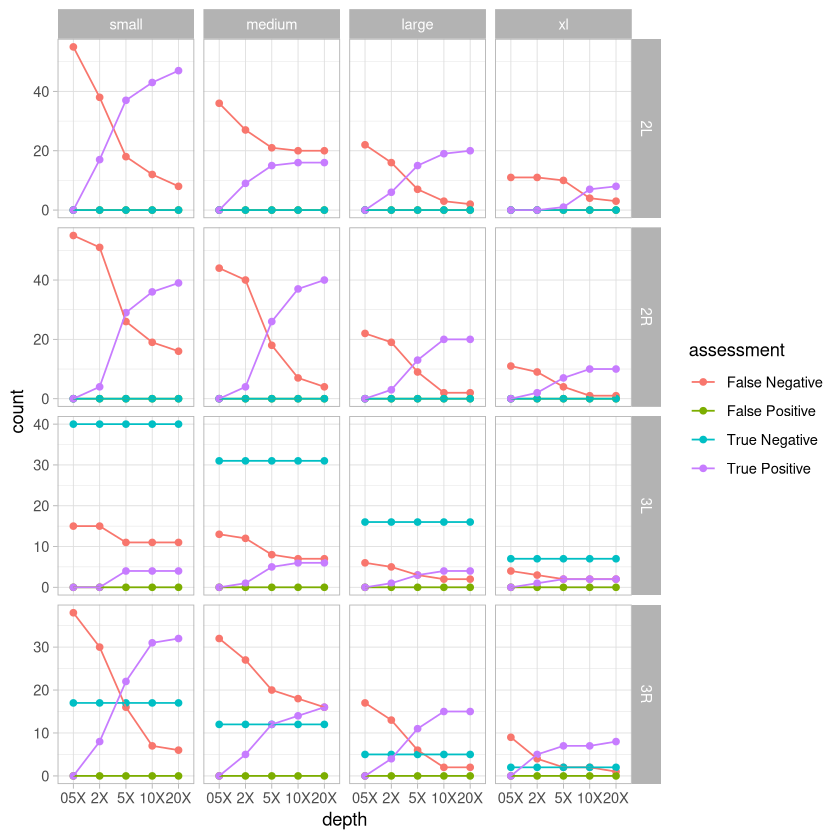

In [115]:
ggplot(assessment_by_contig, aes(x = depth, y = count, color = assessment, group = assessment)) +
    geom_point() +
    geom_line() +
    theme_light() +
    facet_grid(rows = vars(contig), cols = vars(size), scales = "free_y")

Let's plot it with percentages, which should be more revealing

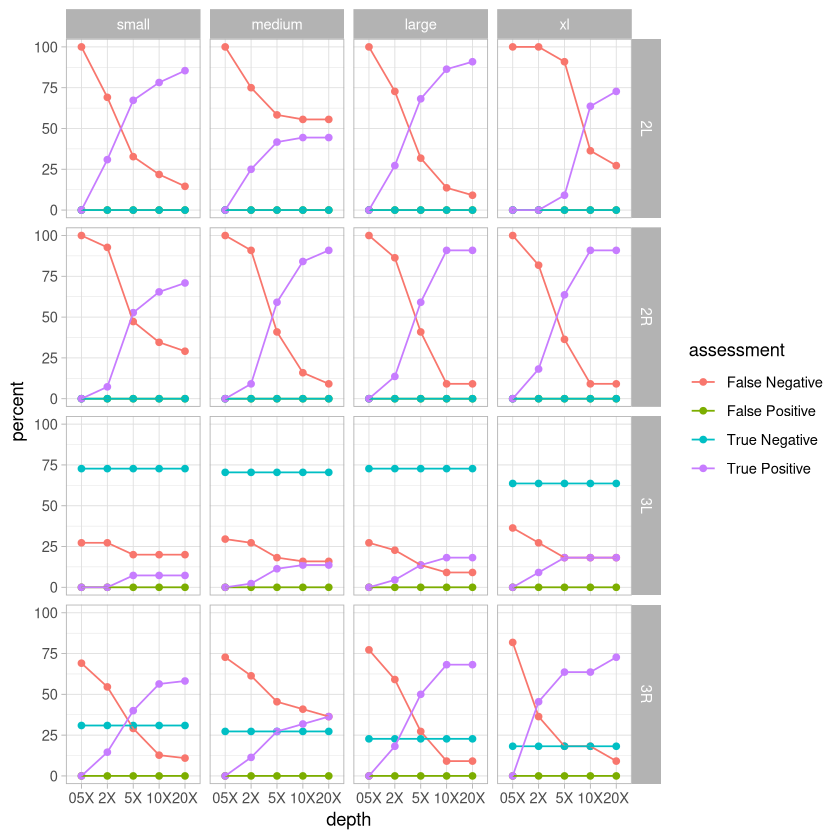

In [130]:
ggplot(assessment_by_contig, aes(x = depth, y = percent, color = assessment, group = assessment)) +
    geom_point() +
    geom_line() +
    theme_light() +
    facet_grid(rows = vars(contig), cols = vars(size))

### Summarize by zygosity

_Oh hey_, that's looking like something. Pretty exciting, actually. There are no false positives, which is great. What about what this looks like taking the zygosity into consideration? Let's also add a percent in addition to the absolute count.

In [126]:
assessment_by_contig_state <- group_by(assessment, size, state, contig, depth, assessment) %>% 
    summarize_at("count", ~ sum(.x)) %>%
    group_by(size, state, contig, depth) %>%
    mutate(percent = count/sum(count) * 100)
head(assessment_by_contig_state)

size,state,contig,depth,assessment,count,percent
<fct>,<chr>,<chr>,<fct>,<chr>,<int>,<dbl>
small,het,2R,05X,False Negative,51,100.00000
small,het,2R,05X,False Positive,0,0.00000
small,het,2R,05X,True Negative,0,0.00000
small,het,2R,05X,True Positive,0,0.00000
small,het,2R,2X,False Negative,47,92.15686
small,het,2R,2X,False Positive,0,0.00000


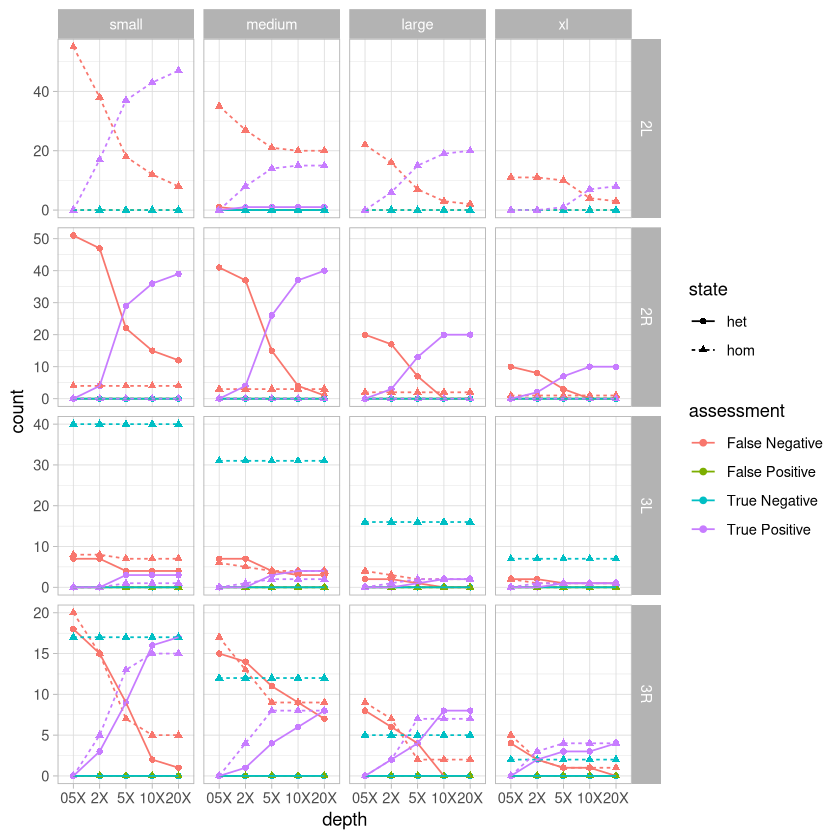

In [117]:
ggplot(assessment_by_contig_state, aes(x = depth, y = count, color = assessment, shape = state, group = paste(assessment, state))) +
    geom_point() +
    geom_line(aes(linetype = state)) +
    theme_light() +
    facet_grid(rows = vars(contig), cols = vars(size), scales = "free_y")

Let's plot it with ratios again

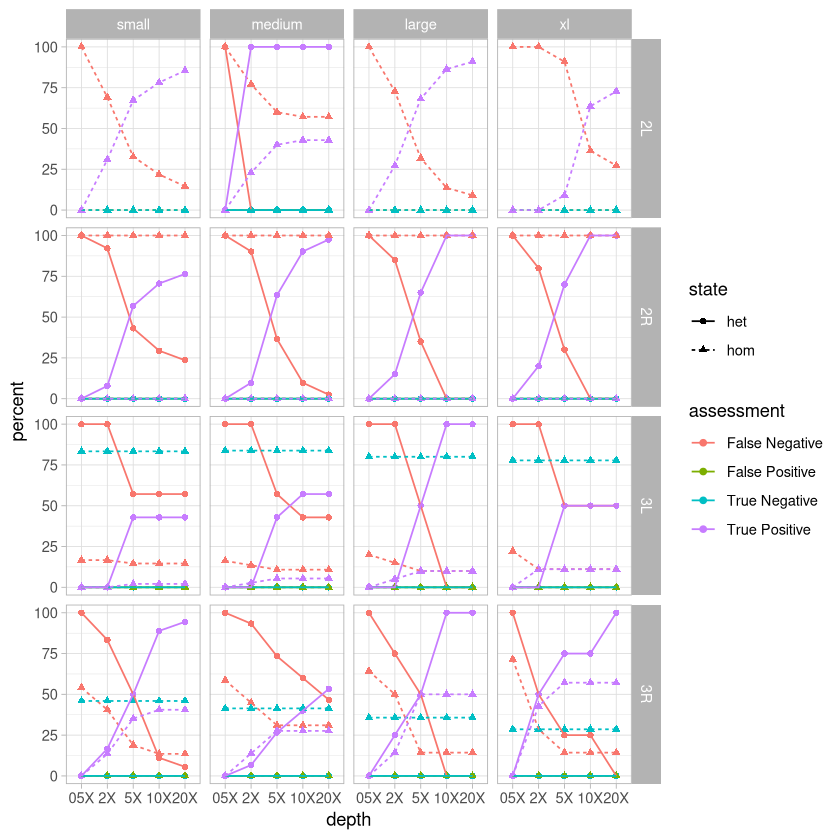

In [132]:
ggplot(assessment_by_contig_state, aes(x = depth, y = percent, color = assessment, shape = state, group = paste(assessment, state))) +
    geom_point() +
    geom_line(aes(linetype = state)) +
    theme_light() +
    facet_grid(rows = vars(contig), cols = vars(size))